In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install h5py

In [ ]:
"""
ARU-GD Training Script — Optimised for NVIDIA H100
Changes from notebook:
  - Full dataset loaded into RAM at startup (no chunk-based loading)
  - Batch size increased to 32 (H100 has 80 GB HBM2e)
  - XLA / tf.function JIT compilation enabled
  - tf.data pipeline with cache + prefetch on GPU
  - All plt.show() replaced with savefig()
  - Windows back-slash paths replaced with Linux forward-slash paths
  - Monte Carlo Dropout uncertainty estimation preserved exactly
"""

# ── 0. Environment setup (must be first) ─────────────────────────────────────
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'          # single H100
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=2'  # enable XLA globally

import tensorflow as tf

# H100: let TF manage memory — do NOT set memory_growth; it conflicts with XLA
physical_devices = tf.config.list_physical_devices('GPU')
print(f"GPUs detected: {len(physical_devices)}")
for d in physical_devices:
    print(f"  {d}")

from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_bfloat16')
mixed_precision.set_global_policy(policy)
print(f"Mixed precision policy: {policy.name}")

# ── 1. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib
matplotlib.use('Agg')          # non-interactive backend — safe on headless nodes
import matplotlib.pyplot as plt
import h5py
import keras
from keras.layers import (Conv2D, Activation, Input, Dropout, MaxPooling2D,
                           UpSampling2D, Conv2DTranspose, Concatenate, multiply,
                           Add, LeakyReLU, BatchNormalization)
from keras.models import Model
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
from keras import regularizers
import tensorflow.keras.backend as K
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── 2. Paths ──────────────────────────────────────────────────────────────────
BASE_DIR        = '/kaggle/input/datasets/harshvardhansg/brtas-my'
OUT_DIR = '/kaggle/working/'
TRAIN_H5        = os.path.join(BASE_DIR, 'h5_dataset', 'train_data.h5')
VALID_H5        = os.path.join(BASE_DIR, 'h5_dataset', 'valid_data.h5')
TEST_H5         = os.path.join(BASE_DIR, 'h5_dataset', 'test_data.h5')
SAVED_MODELS    = os.path.join(OUT_DIR, 'saved_models')
PLOTS_DIR       = os.path.join(OUT_DIR, 'plots')
PREDICTIONS_DIR = os.path.join(OUT_DIR, 'predictions')

for d in [SAVED_MODELS, PLOTS_DIR, PREDICTIONS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── 3. Training hyper-parameters ──────────────────────────────────────────────
BATCH_SIZE   = 16       # H100 can handle much larger batches than the original 8
IMAGE_SHAPE  = (240, 240, 4)
MASK_SHAPE   = (240, 240, 4)
EPOCHS       = 100
DROPOUT_RATE = 0.2
MC_SAMPLES   = 20        # Monte Carlo forward passes for uncertainty

# ── 4. Data augmentation generators ──────────────────────────────────────────
aug_kwargs = dict(
    rotation_range=10,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
)
image_datagen = ImageDataGenerator(**aug_kwargs)
mask_datagen  = ImageDataGenerator(**aug_kwargs)

# ── 5. Load FULL dataset into RAM ─────────────────────────────────────────────
print("\n── Reading dataset metadata only ──")

with h5py.File(TRAIN_H5, 'r') as f:
    num_train_samples = f['X'].shape[0]

with h5py.File(VALID_H5, 'r') as f:
    num_valid_samples = f['X'].shape[0]

with h5py.File(TEST_H5, 'r') as f:
    num_test_samples = f['X'].shape[0]

print(f"Train samples: {num_train_samples}")
print(f"Valid samples: {num_valid_samples}")
print(f"Test samples : {num_test_samples}")

steps_per_epoch   = num_train_samples // BATCH_SIZE
validation_steps  = num_valid_samples // BATCH_SIZE
test_steps        = num_test_samples  // BATCH_SIZE

print(f"\n  Steps per epoch : {steps_per_epoch}")
print(f"  Validation steps: {validation_steps}")
print(f"  Test steps      : {test_steps}")

# ── 6. Augmentation helper (NumPy, applied before tf.data) ───────────────────
def apply_augmentation(X: np.ndarray, Y: np.ndarray) -> tuple:
    """Apply identical random transform to every (x, y) pair in a batch."""
    X_aug = np.empty_like(X)
    Y_aug = np.empty_like(Y)
    for i in range(X.shape[0]):
        transform = image_datagen.get_random_transform(X[i].shape)
        X_aug[i] = image_datagen.apply_transform(X[i], transform)
        Y_aug[i] = image_datagen.apply_transform(Y[i], transform)
    return X_aug, Y_aug


    
def h5_generator(h5_path, batch_size, augment=False):
    while True:
        with h5py.File(h5_path, "r") as f:
            X = f["X"]
            Y = f["Y"]
            n = X.shape[0]

            # create shuffled indices ONLY ONCE per epoch
            indices = np.arange(n)
            if augment:
                np.random.shuffle(indices)

            # iterate sequentially (FAST)
            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)

                batch_idx = indices[start:end]

                # ✅ IMPORTANT: load one-by-one (avoids fancy indexing)
                x_batch = np.stack([X[i] for i in batch_idx]).astype(np.float32)
                y_batch = np.stack([Y[i] for i in batch_idx]).astype(np.float32)

                if augment:
                    x_batch, y_batch = apply_augmentation(x_batch, y_batch)

                yield x_batch, {
                    "final_output": y_batch,
                    "out_3": y_batch,
                    "out_2": y_batch,
                    "out_1": y_batch,
                }
train_dataset = tf.data.Dataset.from_generator(
    lambda: h5_generator(TRAIN_H5, BATCH_SIZE, augment=True),
    output_signature=(
        tf.TensorSpec(shape=(None, *IMAGE_SHAPE), dtype=tf.float32),
        {
            "final_output": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
            "out_3": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
            "out_2": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
            "out_1": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
        },
    ),
).shuffle(8).prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_generator(
    lambda: h5_generator(VALID_H5, BATCH_SIZE, augment=False),
    output_signature=(
        tf.TensorSpec(shape=(None, *IMAGE_SHAPE), dtype=tf.float32),
        {
            "final_output": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
            "out_3": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
            "out_2": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
            "out_1": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
        },
    ),
).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_generator(
    lambda: h5_generator(TEST_H5, BATCH_SIZE, augment=False),
    output_signature=(
        tf.TensorSpec(shape=(None, *IMAGE_SHAPE), dtype=tf.float32),
        {
            "final_output": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
            "out_3": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
            "out_2": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
            "out_1": tf.TensorSpec(shape=(None, *MASK_SHAPE), dtype=tf.float32),
        },
    ),
).prefetch(tf.data.AUTOTUNE)

# Quick shape check
for xb, yb in train_dataset.take(1):
    print(f"\n  Train batch — X: {xb.shape}  Y['final_output']: {yb['final_output'].shape}")

# ── 8. Model definition (unchanged logic) ────────────────────────────────────
def attention_block2d(x, g, inter_channel, i, data_format='channels_last'):
    theta_x    = Conv2D(inter_channel, [2, 2], strides=[2, 2],
                        data_format=data_format,
                        kernel_regularizer=regularizers.l2(1e-5))(x)
    phi_g      = Conv2D(inter_channel, [1, 1], strides=[1, 1],
                        dilation_rate=i, data_format=data_format,
                        kernel_regularizer=regularizers.l2(1e-5))(g)
    f          = LeakyReLU(alpha=0.2)(Add()([theta_x, phi_g]))
    psi_f      = Conv2D(1, [1, 1], strides=[1, 1], dilation_rate=i,
                        data_format=data_format,
                        kernel_regularizer=regularizers.l2(1e-5))(f)
    sigm_psi_f = Activation('sigmoid')(psi_f)
    rate       = UpSampling2D(size=[2, 2])(sigm_psi_f)
    return multiply([x, rate])


def res_block(x, nb_filters, strides, i):
    res_path = BatchNormalization()(x)
    res_path = LeakyReLU(alpha=0.2)(res_path)
    pool     = MaxPooling2D(pool_size=(2, 2))(res_path)
    res_path = Conv2D(filters=nb_filters[0], kernel_size=(3, 3), padding='same',
                      dilation_rate=i, strides=strides[1],
                      kernel_regularizer=regularizers.l2(1e-5))(pool)
    res_path = BatchNormalization()(res_path)
    res_path = LeakyReLU(alpha=0.2)(res_path)
    res_path = Conv2D(filters=nb_filters[1], kernel_size=(3, 3), padding='same',
                      dilation_rate=i, strides=strides[1],
                      kernel_regularizer=regularizers.l2(1e-5))(res_path)
    shortcut = Conv2D(nb_filters[1], kernel_size=(1, 1), dilation_rate=i,
                      strides=strides[1],
                      kernel_regularizer=regularizers.l2(1e-5))(pool)
    shortcut = BatchNormalization()(shortcut)
    return Add()([shortcut, res_path])


def encoder(x):
    to_decoder = []
    main_path  = Conv2D(filters=64, kernel_size=(3, 3), padding='same',
                        dilation_rate=(1, 1), strides=(1, 1),
                        kernel_regularizer=regularizers.l2(1e-5))(x)
    main_path  = BatchNormalization()(main_path)
    main_path  = LeakyReLU(alpha=0.2)(main_path)
    main_path  = Conv2D(filters=64, kernel_size=(3, 3), padding='same',
                        dilation_rate=(1, 1), strides=(1, 1),
                        kernel_regularizer=regularizers.l2(1e-5))(main_path)
    shortcut   = Conv2D(filters=64, kernel_size=(1, 1), strides=(1, 1),
                        dilation_rate=(1, 1),
                        kernel_regularizer=regularizers.l2(1e-5))(x)
    shortcut   = BatchNormalization()(shortcut)
    main_path  = Add()([shortcut, main_path])
    to_decoder.append(main_path)
    main_path = res_block(main_path, [128, 128], [(2, 2), (1, 1)], (1, 1))
    to_decoder.append(main_path)
    main_path = res_block(main_path, [256, 256], [(2, 2), (1, 1)], (2, 2))
    to_decoder.append(main_path)
    main_path = res_block(main_path, [512, 512], [(2, 2), (1, 1)], (4, 4))
    to_decoder.append(main_path)
    return to_decoder


def res_block_decoder(x, nb_filters, strides, i):
    res_path = BatchNormalization()(x)
    res_path = LeakyReLU(alpha=0.2)(res_path)
    res_path = Conv2D(filters=nb_filters[0], kernel_size=(3, 3), padding='same',
                      dilation_rate=i, strides=strides[1],
                      kernel_regularizer=regularizers.l2(1e-5))(res_path)
    res_path = BatchNormalization()(res_path)
    res_path = LeakyReLU(alpha=0.2)(res_path)
    res_path = Conv2D(filters=nb_filters[1], kernel_size=(3, 3), padding='same',
                      dilation_rate=i, strides=strides[1],
                      kernel_regularizer=regularizers.l2(1e-5))(res_path)
    shortcut = Conv2D(nb_filters[1], kernel_size=(1, 1), strides=strides[1],
                      dilation_rate=i,
                      kernel_regularizer=regularizers.l2(1e-5))(x)
    shortcut = BatchNormalization()(shortcut)
    return Add()([shortcut, res_path])


def three_times_sample(main_path):
    h = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same',
                        dilation_rate=(1, 1),
                        kernel_regularizer=regularizers.l2(1e-5))(main_path)
    h = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same',
                        dilation_rate=(1, 1),
                        kernel_regularizer=regularizers.l2(1e-5))(h)
    h = Conv2DTranspose(64,  (2, 2), strides=(2, 2), padding='same',
                        dilation_rate=(1, 1),
                        kernel_regularizer=regularizers.l2(1e-5))(h)
    return h

def two_times_sample(main_path):
    h = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same',
                        dilation_rate=(1, 1),
                        kernel_regularizer=regularizers.l2(1e-5))(main_path)
    h = Conv2DTranspose(64,  (2, 2), strides=(2, 2), padding='same',
                        dilation_rate=(1, 1),
                        kernel_regularizer=regularizers.l2(1e-5))(h)
    return h

def one_time_sample(main_path):
    return Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same',
                           dilation_rate=(1, 1),
                           kernel_regularizer=regularizers.l2(1e-5))(main_path)


def decoder(x, from_encoder, dropout_rate=0.2):
    # Level 1
    att1        = attention_block2d(from_encoder[3], x, 256, (1, 1))
    mp1         = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same',
                                  dilation_rate=(1, 1),
                                  kernel_regularizer=regularizers.l2(1e-5))(x)
    mp1         = Concatenate()([mp1, att1])
    mp1         = res_block_decoder(mp1, [512, 512], [(1, 1), (1, 1)], (4, 4))
    mp1         = Dropout(dropout_rate)(mp1)          # Monte Carlo Dropout
    hc1         = three_times_sample(mp1)
    out_1       = Conv2D(4, (1, 1), activation='softmax', name='out_1')(hc1)

    # Level 2
    att2        = attention_block2d(from_encoder[2], mp1, 128, (1, 1))
    mp2         = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same',
                                  dilation_rate=(1, 1),
                                  kernel_regularizer=regularizers.l2(1e-5))(mp1)
    mp2         = Concatenate()([mp2, att2])
    mp2         = res_block_decoder(mp2, [256, 256], [(1, 1), (1, 1)], (2, 2))
    mp2         = Dropout(dropout_rate)(mp2)          # Monte Carlo Dropout
    hc2         = two_times_sample(mp2)
    out_2       = Conv2D(4, (1, 1), activation='softmax', name='out_2')(hc2)

    # Level 3
    att3        = attention_block2d(from_encoder[1], mp2, 64, (1, 1))
    mp3         = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same',
                                  dilation_rate=(1, 1),
                                  kernel_regularizer=regularizers.l2(1e-5))(mp2)
    mp3         = Concatenate()([mp3, att3])
    mp3         = res_block_decoder(mp3, [128, 128], [(1, 1), (1, 1)], (1, 1))
    mp3         = Dropout(dropout_rate)(mp3)          # Monte Carlo Dropout
    hc3         = one_time_sample(mp3)
    out_3       = Conv2D(4, (1, 1), activation='softmax', name='out_3')(hc3)

    # Level 4 (final)
    att4        = attention_block2d(from_encoder[0], mp3, 32, (1, 1))
    mp4         = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same',
                                  dilation_rate=(1, 1),
                                  kernel_regularizer=regularizers.l2(1e-5))(mp3)
    mp4         = Concatenate()([mp4, att4])
    mp4         = res_block_decoder(mp4, [64, 64], [(1, 1), (1, 1)], (1, 1))
    mp4         = Dropout(dropout_rate)(mp4)          # Monte Carlo Dropout
    return mp4, out_3, out_2, out_1


def aru_gd(input_shape, dropout_rate=0.2):
    inputs         = Input(shape=input_shape)
    to_decoder     = encoder(inputs)
    path           = res_block(to_decoder[3], [1024, 1024], [(2, 2), (1, 1)], (8, 8))
    final_out, out_3, out_2, out_1 = decoder(
        path, from_encoder=to_decoder, dropout_rate=dropout_rate)
    final_out      = Conv2D(4, (1, 1), activation='softmax',
                            name='final_output')(final_out)
    return Model(inputs=inputs, outputs=[final_out, out_3, out_2, out_1])

# ── 9. Loss / metric functions (unchanged logic) ──────────────────────────────
def dice_coef_0(y_true, y_pred, smooth=1e-6):
    yt = K.flatten(y_true[:, :, :, 0])
    yp = K.flatten(y_pred[:, :, :, 0])
    return (2. * K.sum(yt * yp) + smooth) / (K.sum(yt) + K.sum(yp) + smooth)

def dice_coef_1(y_true, y_pred, smooth=1e-6):
    yt = K.flatten(y_true[:, :, :, 1])
    yp = K.flatten(y_pred[:, :, :, 1])
    return (2. * K.sum(yt * yp) + smooth) / (K.sum(yt) + K.sum(yp) + smooth)

def dice_coef_2(y_true, y_pred, smooth=1e-6):
    yt = K.flatten(y_true[:, :, :, 2])
    yp = K.flatten(y_pred[:, :, :, 2])
    return (2. * K.sum(yt * yp) + smooth) / (K.sum(yt) + K.sum(yp) + smooth)

def dice_coef_3(y_true, y_pred, smooth=1e-6):
    yt = K.flatten(y_true[:, :, :, 3])
    yp = K.flatten(y_pred[:, :, :, 3])
    return (2. * K.sum(yt * yp) + smooth) / (K.sum(yt) + K.sum(yp) + smooth)

def dice_score(y_true, y_pred):
    return (dice_coef_0(y_true, y_pred) + dice_coef_1(y_true, y_pred) +
            dice_coef_2(y_true, y_pred) + dice_coef_3(y_true, y_pred)) / 4.0

def weighted_dice_score(y_true, y_pred):
    return (dice_coef_0(y_true, y_pred) +
            5 * dice_coef_1(y_true, y_pred) +
            2 * dice_coef_2(y_true, y_pred) +
            4 * dice_coef_3(y_true, y_pred)) / 12.0

def dice_loss(y_true, y_pred):
    return 1.0 - dice_score(y_true, y_pred)

def weighted_dice_loss(y_true, y_pred):
    return 1.0 - weighted_dice_score(y_true, y_pred)

def weighted_log_loss(y_true, y_pred):
    y_true  = tf.cast(y_true, tf.float32)
    y_pred  = tf.cast(y_pred, tf.float32)
    y_pred  = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())
    weights = tf.constant([1, 5, 2, 4], dtype=tf.float32)
    loss    = y_true * tf.math.log(y_pred) * weights
    return tf.reduce_mean(-tf.reduce_sum(loss, axis=-1))

def gen_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return weighted_dice_loss(y_true, y_pred) + weighted_log_loss(y_true, y_pred)

# ── 10. Build and compile model ───────────────────────────────────────────────
print("\n── Building model ──")
tf.keras.backend.clear_session()

losses = {
    'final_output': gen_dice_loss,
    'out_3':        gen_dice_loss,
    'out_2':        gen_dice_loss,
    'out_1':        gen_dice_loss,
}
loss_weights = {'final_output': 0.5, 'out_3': 0.125, 'out_2': 0.125, 'out_1': 0.125}

optimizer = Adam(learning_rate=0.0001)

model = aru_gd(IMAGE_SHAPE, dropout_rate=DROPOUT_RATE)
model.compile(
    optimizer=optimizer,
    loss=losses,
    loss_weights=loss_weights,
    metrics={k: dice_score for k in losses},
    jit_compile=True,           # XLA compilation — big speed-up on H100
)
model.summary()

# ── 11. Callbacks ─────────────────────────────────────────────────────────────
CKPT_PATH = os.path.join(SAVED_MODELS, 'model_v5_3.h5')

checkpoint = ModelCheckpoint(
    CKPT_PATH,
    save_best_only=True,
    monitor='val_loss',
    verbose=1,
    mode='min',
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6,
)

# ── 12. Training ──────────────────────────────────────────────────────────────
print("\n── Training ──")
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    verbose=1,
    callbacks=[checkpoint, reduce_lr],
)

# Save final model
final_path = os.path.join(SAVED_MODELS, 'model_v5_3_final.h5')
model.save(final_path, include_optimizer=True)
print(f"Final model saved → {final_path}")

# ── 13. Save training history plots ──────────────────────────────────────────
print("\n── Saving training plots ──")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['final_output_dice_score'],     label='Train Dice (Final)')
axes[1].plot(history.history['val_final_output_dice_score'], label='Val Dice (Final)')
axes[1].set_title('Dice Score (Final Output)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].legend()

plt.tight_layout()
loss_plot_path = os.path.join(PLOTS_DIR, 'training_history.png')
plt.savefig(loss_plot_path, dpi=150)
plt.close()
print(f"  Training history plot saved → {loss_plot_path}")

# ── 14. Test evaluation ───────────────────────────────────────────────────────
print("\n── Evaluating on test set ──")
test_results = model.evaluate(
    test_dataset,
    verbose=1,
    return_dict=True,
)
print("\nTest Results:")
for out in ['final_output', 'out_3', 'out_2', 'out_1']:
    print(f"  {out}:")
    print(f"    Loss       : {test_results[f'{out}_loss']:.4f}")
    print(f"    Dice Score : {test_results[f'{out}_dice_score']:.4f}")

# ── 15. Monte Carlo Dropout — uncertainty estimation ─────────────────────────
print(f"\n── Computing MC-Dropout uncertainty ({MC_SAMPLES} samples) ──")

with h5py.File(TEST_H5, "r") as f:
    X_test = f["X"][:]
    Y_test = f["Y"][:]

# Run MC-Dropout inference with training=True so Dropout stays active
@tf.function(jit_compile=True)
def mc_forward(x):
    # training=True keeps dropout active for uncertainty estimation
    return model(x, training=True)[0]   # [0] = final_output

input_images   = X_test
ground_truth   = np.argmax(Y_test, axis=-1)           # (N, 240, 240)

mc_preds = []
for s in range(MC_SAMPLES):
    preds = []
    for start in range(0, num_test_samples, BATCH_SIZE):
        end   = min(start + BATCH_SIZE, num_test_samples)
        batch = tf.constant(input_images[start:end])
        preds.append(mc_forward(batch).numpy())
    mc_preds.append(np.concatenate(preds, axis=0))     # (N, 240, 240, 4)
    print(f"  MC sample {s+1}/{MC_SAMPLES} done", end='\r')

print()

mc_preds        = np.stack(mc_preds, axis=0)           # (MC, N, 240, 240, 4)
mean_pred       = mc_preds.mean(axis=0)                # (N, 240, 240, 4)
variance        = mc_preds.var(axis=0)                 # (N, 240, 240, 4)

predicted_images  = np.argmax(mean_pred, axis=-1)      # (N, 240, 240)
uncertainty_maps  = variance.mean(axis=-1)             # (N, 240, 240) — mean over classes

# Normalise uncertainty to [0, 1]
u_min, u_max  = uncertainty_maps.min(), uncertainty_maps.max()
uncertainty_maps = (uncertainty_maps - u_min) / (u_max - u_min + 1e-8)

# ── 16. Save prediction visualisations ───────────────────────────────────────
print("\n── Saving prediction visualisations ──")

# Single highlighted slice (slice 550)
slice_idx = min(550, num_test_samples - 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(ground_truth[slice_idx],    cmap='gray')
axes[0].set_title(f'Ground Truth (Slice {slice_idx})', fontsize=10)
axes[0].axis('off')
axes[1].imshow(predicted_images[slice_idx], cmap='gray')
axes[1].set_title(f'Prediction (Slice {slice_idx})', fontsize=10)
axes[1].axis('off')
im = axes[2].imshow(uncertainty_maps[slice_idx], cmap='RdYlGn_r', vmin=0, vmax=1)
axes[2].set_title(f'Uncertainty Map (Slice {slice_idx})', fontsize=10)
plt.colorbar(im, ax=axes[2], label='Uncertainty (0=Low, 1=High)',
             fraction=0.046, pad=0.04)
axes[2].axis('off')
plt.tight_layout()
single_path = os.path.join(PLOTS_DIR, f'prediction_slice_{slice_idx}.png')
plt.savefig(single_path, dpi=150)
plt.close()
print(f"  Single-slice plot saved → {single_path}")

# Grid of slices (every 50 slices)
for i in range(0, 1000, 50):
    if i >= num_test_samples:
        break
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes[0, 0].imshow(input_images[i, :, :, 0], cmap='gray')
    axes[0, 0].set_title(f'Input FLAIR (Slice {i})', fontsize=12)
    axes[0, 0].axis('off')
    axes[0, 1].imshow(ground_truth[i], cmap='gray')
    axes[0, 1].set_title(f'Ground Truth (Slice {i})', fontsize=12)
    axes[0, 1].axis('off')
    axes[1, 0].imshow(predicted_images[i], cmap='gray')
    axes[1, 0].set_title(f'Prediction (Slice {i})', fontsize=12)
    axes[1, 0].axis('off')
    im = axes[1, 1].imshow(uncertainty_maps[i], cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[1, 1].set_title(f'Uncertainty Map (Slice {i})', fontsize=12)
    plt.colorbar(im, ax=axes[1, 1], label='Uncertainty (0=Low, 1=High)',
                 fraction=0.046, pad=0.04)
    axes[1, 1].axis('off')
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, f'prediction_grid_slice_{i:04d}.png')
    plt.savefig(path, dpi=120)
    plt.close()

print(f"  Grid plots saved → {PLOTS_DIR}/prediction_grid_slice_*.png")

# Save raw arrays for further analysis
np.save(os.path.join(PREDICTIONS_DIR, 'predicted_images.npy'),  predicted_images)
np.save(os.path.join(PREDICTIONS_DIR, 'ground_truth.npy'),       ground_truth)
np.save(os.path.join(PREDICTIONS_DIR, 'uncertainty_maps.npy'),   uncertainty_maps)
np.save(os.path.join(PREDICTIONS_DIR, 'mean_predictions.npy'),   mean_pred)
print(f"  NumPy arrays saved → {PREDICTIONS_DIR}/")

print("\n── All done ──")

GPUs detected: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Mixed precision policy: mixed_bfloat16

── Reading dataset metadata only ──
Train samples: 4700
Valid samples: 775
Test samples : 1000

  Steps per epoch : 293
  Validation steps: 48
  Test steps      : 62

  Train batch — X: (16, 240, 240, 4)  Y['final_output']: (16, 240, 240, 4)

── Building model ──


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 240, 240,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 240, 240,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 240, 240,  │        320 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 240,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 240, 240,  │     36,928 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 240, 240,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 240,  │        256 │ add[0][0]         │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 120, 120,  │          0 │ leaky_re_lu_1[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 120, 120,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 120, 120,  │      8,320 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 120, 120,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 120, 120,  │    147,584 │ leaky_re_lu_2[0]

 Total params: 34,395,572 (131.21 MB)

...

293/293 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - final_output_dice_score: 0.8753 - final_output_loss: 0.1979 - loss: 0.2537 - out_1_dice_score: 0.8337 - out_1_loss: 0.2624 - out_2_dice_score: 0.8602 - out_2_loss: 0.2202 - out_3_dice_score: 0.8727 - out_3_loss: 0.2007 - val_final_output_dice_score: 0.7125 - val_final_output_loss: 0.4612 - val_loss: 0.4867 - val_out_1_dice_score: 0.6586 - val_out_1_loss: 0.5417 - val_out_2_dice_score: 0.6940 - val_out_2_loss: 0.4876 - val_out_3_dice_score: 0.7089 - val_out_3_loss: 0.4680 - learning_rate: 2.5000e-05
Epoch 24/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - final_output_dice_score: 0.8729 - final_output_loss: 0.2027 - loss: 0.2575 - out_1_dice_score: 0.8311 - out_1_loss: 0.2681 - out_2_dice_score: 0.8581 - out_2_loss: 0.2248 - out_3_dice_score: 0.8705 - out_3_loss: 0.2052
Epoch 24: val_loss did not improve from 0.48671
293/293 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - final_output_dice_score: 0.8729 - final_output_loss: 0.2027 - loss: 0.2575 - out_1_

293/293 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - final_output_dice_score: 0.8785 - final_output_loss: 0.1946 - loss: 0.2497 - out_1_dice_score: 0.8376 - out_1_loss: 0.2588 - out_2_dice_score: 0.8637 - out_2_loss: 0.2165 - out_3_dice_score: 0.8760 - out_3_loss: 0.1972 - val_final_output_dice_score: 0.7217 - val_final_output_loss: 0.4413 - val_loss: 0.4740 - val_out_1_dice_score: 0.6532 - val_out_1_loss: 0.5560 - val_out_2_dice_score: 0.6972 - val_out_2_loss: 0.4825 - val_out_3_dice_score: 0.7192 - val_out_3_loss: 0.4441 - learning_rate: 2.5000e-05
Epoch 26/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 875ms/step - final_output_dice_score: 0.8745 - final_output_loss: 0.2002 - loss: 0.2545 - out_1_dice_score: 0.8325 - out_1_loss: 0.2664 - out_2_dice_score: 0.8595 - out_2_loss: 0.2228 - out_3_dice_score: 0.8720 - out_3_loss: 0.2029
Epoch 26: val_loss did not improve from 0.47400
293/293 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - final_output_dice_score: 0.8745 - final_output_loss: 0.2002 - loss: 0.2545 - out_1_

293/293 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - final_output_dice_score: 0.8806 - final_output_loss: 0.1896 - loss: 0.2434 - out_1_dice_score: 0.8395 - out_1_loss: 0.2541 - out_2_dice_score: 0.8659 - out_2_loss: 0.2118 - out_3_dice_score: 0.8783 - out_3_loss: 0.1923 - val_final_output_dice_score: 0.7206 - val_final_output_loss: 0.4392 - val_loss: 0.4646 - val_out_1_dice_score: 0.6678 - val_out_1_loss: 0.5208 - val_out_2_dice_score: 0.7021 - val_out_2_loss: 0.4677 - val_out_3_dice_score: 0.7169 - val_out_3_loss: 0.4438 - learning_rate: 2.5000e-05
Epoch 31/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - final_output_dice_score: 0.8783 - final_output_loss: 0.1928 - loss: 0.2460 - out_1_dice_score: 0.8363 - out_1_loss: 0.2588 - out_2_dice_score: 0.8633 - out_2_loss: 0.2151 - out_3_dice_score: 0.8759 - out_3_loss: 0.1955
Epoch 31: val_loss did not improve from 0.46461
293/293 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - final_output_dice_score: 0.8783 - final_output_loss: 0.1928 - loss: 0.2460 - out_1_

293/293 ━━━━━━━━━━━━━━━━━━━━ 339s 1s/step - final_output_dice_score: 0.8879 - final_output_loss: 0.1788 - loss: 0.2306 - out_1_dice_score: 0.8468 - out_1_loss: 0.2429 - out_2_dice_score: 0.8730 - out_2_loss: 0.2011 - out_3_dice_score: 0.8853 - out_3_loss: 0.1818 - val_final_output_dice_score: 0.7192 - val_final_output_loss: 0.4398 - val_loss: 0.4646 - val_out_1_dice_score: 0.6605 - val_out_1_loss: 0.5337 - val_out_2_dice_score: 0.6967 - val_out_2_loss: 0.4765 - val_out_3_dice_score: 0.7152 - val_out_3_loss: 0.4439 - learning_rate: 6.2500e-06
Epoch 44/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 999ms/step - final_output_dice_score: 0.8903 - final_output_loss: 0.1739 - loss: 0.2262 - out_1_dice_score: 0.8497 - out_1_loss: 0.2373 - out_2_dice_score: 0.8758 - out_2_loss: 0.1958 - out_3_dice_score: 0.8879 - out_3_loss: 0.1768
Epoch 44: val_loss did not improve from 0.46459
293/293 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - final_output_dice_score: 0.8903 - final_output_loss: 0.1739 - loss: 0.2262 - out_1_

Final model saved → /kaggle/working/saved_models/model_v5_3_final.h5

── Saving training plots ──
  Training history plot saved → /kaggle/working/plots/training_history.png

── Evaluating on test set ──
   9872/Unknown 6033s 611ms/step - final_output_dice_score: 0.7300 - final_output_loss: 0.4441 - loss: 0.4578 - out_1_dice_score: 0.6866 - out_1_loss: 0.5019 - out_2_dice_score: 0.7123 - out_2_loss: 0.4689 - out_3_dice_score: 0.7273 - out_3_loss: 0.4467

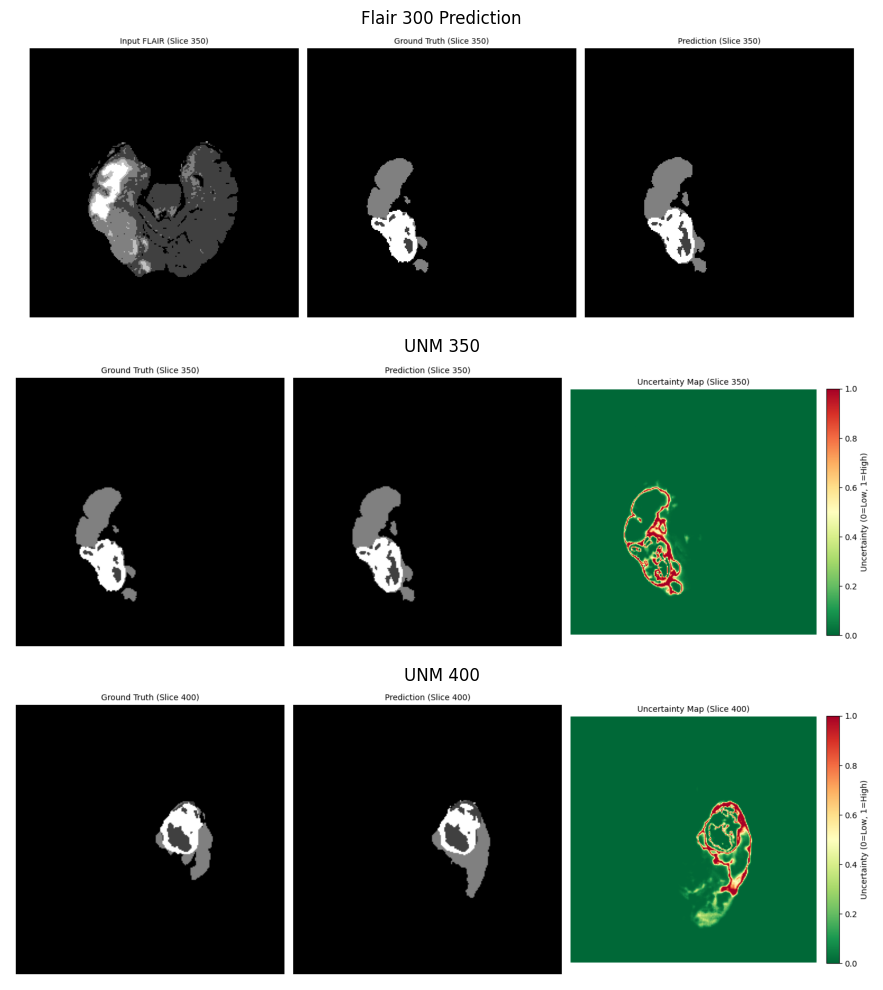

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define your file paths
img1_path = '/Users/harshvardhangupta/Downloads/flair-300_prediction.png'
img2_path = '/Users/harshvardhangupta/Downloads/unm-350.png'
img3_path = '/Users/harshvardhangupta/Downloads/unm-400.png'

# Read the images into NumPy arrays
img1 = mpimg.imread(img1_path)
img2 = mpimg.imread(img2_path)
img3 = mpimg.imread(img3_path)

# Create a figure and a grid of subplots (1 row, 3 columns)
# figsize=(15, 5) makes the overall figure wide enough to fit them nicely
fig, axes = plt.subplots(3, 1, figsize=(25, 10))

# Plot the first image
axes[0].imshow(img1)
axes[0].axis('off') # Hides the axes
axes[0].set_title('Flair 300 Prediction')

# Plot the second image
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title('UNM 350')

# Plot the third image
axes[2].imshow(img3)
axes[2].axis('off')
axes[2].set_title('UNM 400')

# Adjust layout to prevent overlap and display the plot
plt.tight_layout()
plt.show()